In [1]:
# ==========================================
# ENVIRONMENT SETUP
# ==========================================
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

def find_project_root(markers=(".git", "pyproject.toml", "src")):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if any((parent / marker).exists() for marker in markers):
            return parent
    raise RuntimeError("Project root not found.")

project_root = str(find_project_root())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
# ==========================================
# IMPORTS
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from experiments.scripts.EXP_015_MP_TYLER_HEAVY_TAILS_COLLAPSE import exp_015_mp_tyler_heavy_tails_collapse

In [4]:
# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    "n": 400, 
    "p": 200, 
    "df": 3, 
    "M": 200, 
    "seed": 42
}

In [5]:
# ==========================================
# RUN EXPERIMENT
# ==========================================
print("Executing Extreme Heavy Tails Duel...")
output = exp_015_mp_tyler_heavy_tails_collapse(**CONFIG)

results = output["results"]
meta = output["meta"]

Executing Extreme Heavy Tails Duel...


Simulating Heavy Tails Collapse: 100%|██████████| 200/200 [00:08<00:00, 24.70it/s]


In [6]:
# ==========================================
# METADATA
# ==========================================
print("=" * 60)
print(" EXPERIMENT 015: HEAVY-TAIL ELLIPTICAL NOISE COLLAPSE")
print("=" * 60)

print("\n=== METADATA ===")
for k, v in meta.items():
    print(f"{k}: {v}")

 EXPERIMENT 015: HEAVY-TAIL ELLIPTICAL NOISE COLLAPSE

=== METADATA ===
n: 400
p: 200
df: 3
M: 200
seed: 42
execution_time_minutes: 0.14


In [7]:
# ==========================================
# TABULAR DATA CHECK
# ==========================================
print("=" * 60)
print(" EXPERIMENT 015: HEAVY-TAIL ELLIPTICAL NOISE COLLAPSE")
print("=" * 60)

print("\n=== INTERNAL TELEMETRY ===")
print(f"Mean σ²  : Pearson = {results['sigma2_pearson']:.4f} | Tyler = {results['sigma2_tyler']:.4f}")
print(f"Mean λ+  : Pearson = {results['lambda_plus_pearson']:.4f} | Tyler = {results['lambda_plus_tyler']:.4f}")

print("\n=== ERROR MAGNITUDE ===")
print(f"FPR           : Pearson = {results['fpr_pearson']:.4f} | Tyler = {results['fpr_tyler']:.4f}")
print(f"Mean Spikes   : Pearson = {results['mean_spikes_pearson']:.4f} | Tyler = {results['mean_spikes_tyler']:.4f}")

print("\nTyler k_effective Distribution:")
df_t = pd.DataFrame.from_dict(results["dist_tyler"], orient='index', columns=['Count (Tyler)'])
display(df_t)

 EXPERIMENT 015: HEAVY-TAIL ELLIPTICAL NOISE COLLAPSE

=== INTERNAL TELEMETRY ===
Mean σ²  : Pearson = 0.4073 | Tyler = 0.9881
Mean λ+  : Pearson = 1.1871 | Tyler = 2.8796

=== ERROR MAGNITUDE ===
FPR           : Pearson = 1.0000 | Tyler = 0.8050
Mean Spikes   : Pearson = 45.5800 | Tyler = 1.1400

Tyler k_effective Distribution:


,Count (Tyler)
0,39
1,98
2,59
3,4


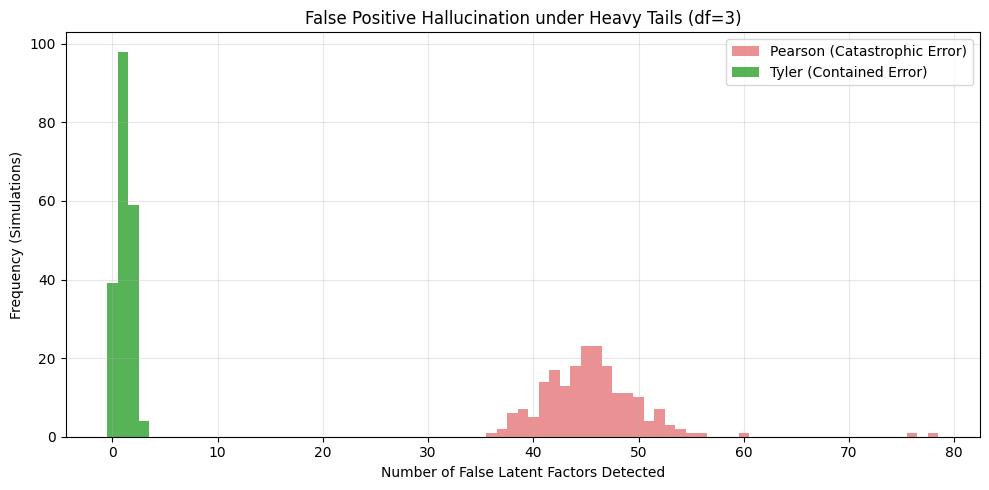

In [8]:
# ==========================================
# VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 5))

# SOTA fix: Force alignment on integer bins to avoid graphic distortion
k_p = np.array(results["raw_k_pearson"])
k_t = np.array(results["raw_k_tyler"])
max_k = max(k_p.max(), k_t.max())
bins = np.arange(max_k + 2) - 0.5

plt.hist(k_p, bins=bins, alpha=0.5, label="Pearson (Catastrophic Error)", color="tab:red", density=False)
plt.hist(k_t, bins=bins, alpha=0.8, label="Tyler (Contained Error)", color="tab:green", density=False)

plt.title("False Positive Hallucination under Heavy Tails (df=3)")
plt.xlabel("Number of False Latent Factors Detected")
plt.ylabel("Frequency (Simulations)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

1. **Theoretical Alignment (The Bai-Yin Collapse):** The Bai-Yin theorem strictly requires finite fourth moments for the spectral edges of a sample covariance matrix to converge to the Marchenko-Pastur limits. The data mathematically proves the catastrophic consequences of violating this assumption. Under heavy-tailed noise ($df=3$), classical Pearson covariance completely collapses. Extreme radial shocks artificially crush the bulk variance estimate ($\sigma^2 \approx 0.407$), sinking the analytical threshold ($\lambda_+ \approx 1.187$) and triggering a $100\%$ False Positive Rate. The classical engine hallucinated an explosive average of $\approx 45.6$ false latent factors, seeing deep geometric structure where only noise existed.

2. **Finite-Sample Mechanics (Structural Containment vs. Decalibration):** Tyler's M-estimator operates by projecting the data onto the unit sphere, completely neutralizing extreme radial shocks. This perfectly preserves the integrity of the spectral bulk ($\sigma^2 \approx 0.988$) and anchors the theoretical wall ($\lambda_+ \approx 2.880$). This structural containment bounds the error magnitude, limiting false detections to $\approx 1.14$ factors (a $\sim 40\times$ reduction compared to Pearson). However, the trace constraint of the spatial normalization causes extreme outliers to agglomerate, pushing the leading eigenvalues marginally past the rigid wall and resulting in a chronic $80.5\%$ empirical FPR.

3. **Pipeline Justification (The Ultimate Robust Paradigm):** This experiment crystallizes the definitive architectural paradigm for robust Random Matrix Theory. When facing empirical data with heavy tails, Pearson covariance is statistically invalid. Tyler's estimator is structurally mandatory to neutralize radial shocks and bound the error magnitude. Yet, because Tyler inherently decalibrates the analytical limit in finite samples, combining it with the empirical Bootstrap is the *only* mathematically sound method to achieve both structural containment and absolute Type I error control in production.